## Extracción de Datos

In [52]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
# Configurar cliente con caché y reintentos
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 7.9,
    "longitude": -72.5,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
    ],
    "timezone": "America/Bogota",
    "past_days": 5,
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Coordenadas: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevación: {response.Elevation()} m snm")
print(f"Offset UTC: {response.UtcOffsetSeconds()}s")

# Procesar variables horarias — el índice debe coincidir con el orden en `hourly`
hourly = response.Hourly()
hourly_temperature_2m      = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity   = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation       = hourly.Variables(2).ValuesAsNumpy()
hourly_rain                = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left",
    ),
    "temperature_2m": hourly_temperature_2m,
    "relative_humidity_2m": hourly_relative_humidity,
    "precipitation": hourly_precipitation,
    "rain": hourly_rain
}

df = pd.DataFrame(data=hourly_data)
print("\nDatos horarios\n", df)

Coordenadas: 7.90861177444458°N -72.49148559570312°E
Elevación: 299.0 m snm
Offset UTC: -18000s

Datos horarios
                          date  temperature_2m  relative_humidity_2m  \
0   2026-05-06 05:00:00+00:00       24.900000             80.434639   
1   2026-05-06 06:00:00+00:00       24.500000             87.302261   
2   2026-05-06 07:00:00+00:00       25.500000             78.809692   
3   2026-05-06 08:00:00+00:00       25.049999             77.545647   
4   2026-05-06 09:00:00+00:00       24.600000             76.527481   
..                        ...             ...                   ...   
283 2026-05-18 00:00:00+00:00       27.750000             61.399342   
284 2026-05-18 01:00:00+00:00       27.299999             62.842201   
285 2026-05-18 02:00:00+00:00       26.850000             64.124962   
286 2026-05-18 03:00:00+00:00       26.500000             64.852524   
287 2026-05-18 04:00:00+00:00       26.150000             65.795723   

     precipitation  rain  
0      

In [54]:
df_bogota = df.copy()

df_bogota["date"] = df_bogota["date"].dt.tz_convert("America/Bogota")
df_bogota = df_bogota.rename(columns={'date': 'datetime'})
df_bogota["hour"] = df_bogota["datetime"].dt.hour
df_bogota["date"] = df_bogota["datetime"].dt.normalize().dt.tz_localize(None)

df_bogota = df_bogota[["datetime","date", "hour", "temperature_2m", "relative_humidity_2m", "precipitation", "rain"]]

df_bogota

,datetime,date,hour,temperature_2m,relative_humidity_2m,precipitation,rain
0,2026-05-06 00:00:00-05:00,2026-05-06,0,24.900000,80.434639,0.0,0.0
1,2026-05-06 01:00:00-05:00,2026-05-06,1,24.500000,87.302261,0.0,0.0
2,2026-05-06 02:00:00-05:00,2026-05-06,2,25.500000,78.809692,0.0,0.0
3,2026-05-06 03:00:00-05:00,2026-05-06,3,25.049999,77.545647,0.0,0.0
4,2026-05-06 04:00:00-05:00,2026-05-06,4,24.600000,76.527481,0.1,0.1
...,...,...,...,...,...,...,...
283,2026-05-17 19:00:00-05:00,2026-05-17,19,27.750000,61.399342,0.0,0.0
284,2026-05-17 20:00:00-05:00,2026-05-17,20,27.299999,62.842201,0.0,0.0
285,2026-05-17 21:00:00-05:00,2026-05-17,21,26.850000,64.124962,0.0,0.0
286,2026-05-17 22:00:00-05:00,2026-05-17,22,26.500000,64.852524,0.0,0.0


### Verificación de los datos

In [55]:
# hay datos nulos
df_bogota.isnull().sum()

datetime                0
date                    0
hour                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
dtype: int64

## Análisis básico

In [56]:
# ¿Cuál es la temperatura promedio?
temperatura_promedio=df_bogota["temperature_2m"].mean()
display(temperatura_promedio)

np.float32(28.344791)

In [57]:
# ¿Cuándo llueve más?
# ¿a qué hora llueve más en promedio?
lluvia_por_hora = df_bogota.groupby("hour")["rain"].mean().sort_values()
display(lluvia_por_hora.head(5))
# ¿qué día llovió más?
lluvia_por_dia = df_bogota.groupby("date")["rain"].sum().sort_values()
display(lluvia_por_dia.head(5))

# El momento exacto de mayor lluvia
idx = df_bogota["rain"].idxmax()
print(df_bogota.loc[idx, ["date", "hour", "rain"]])


hour
0    0.0
1    0.0
2    0.0
3    0.0
5    0.0
Name: rain, dtype: float32

date
2026-05-07    0.0
2026-05-08    0.0
2026-05-09    0.0
2026-05-10    0.0
2026-05-12    0.0
Name: rain, dtype: float32

date    2026-05-06 00:00:00
hour                      4
rain                    0.1
Name: 4, dtype: object


In [58]:
# Matriz limpia, sin redundancia
df_bogota_sin_datetime=df_bogota[["date", "hour", "temperature_2m", "relative_humidity_2m", "precipitation", "rain"]]
df_bogota_sin_datetime.corr()

,date,hour,temperature_2m,relative_humidity_2m,precipitation,rain
date,1.000000e+00,1.184008e-13,-0.079570,-0.003268,-0.113930,-0.094047
hour,1.184008e-13,1.000000e+00,0.368236,-0.279436,-0.056816,-0.063955
temperature_2m,-7.957039e-02,3.682361e-01,1.000000,-0.953841,-0.028535,-0.067451
relative_humidity_2m,-3.267627e-03,-2.794358e-01,-0.953841,1.000000,0.071132,0.076172
precipitation,-1.139298e-01,-5.681611e-02,-0.028535,0.071132,1.000000,0.575335
rain,-9.404687e-02,-6.395537e-02,-0.067451,0.076172,0.575335,1.000000


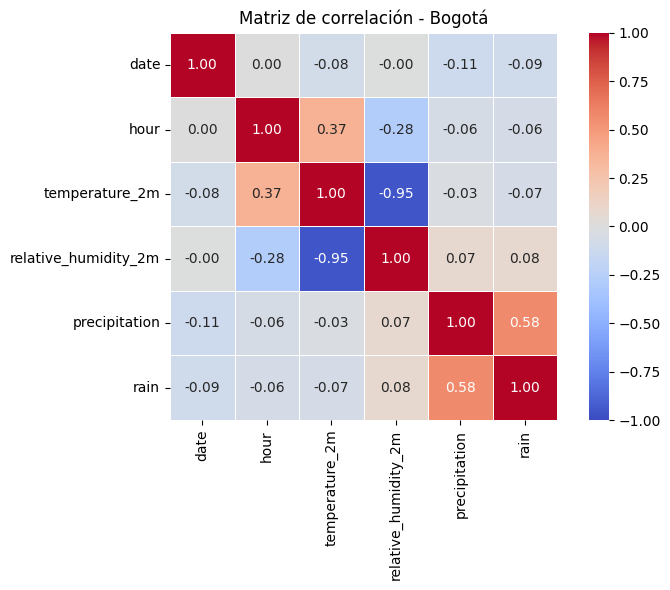

In [59]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_bogota_sin_datetime.corr(),
    annot=True,        # muestra los valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",   # rojo=positivo, azul=negativo
    vmin=-1, vmax=1,   # escala fija
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlación - Bogotá")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.line(df, x='date', y='temperature_2m', title='Temperatura en Bogotá')
fig.show()

In [62]:
fig = px.line(df, x='date', y='precipitation', title='Precipitación en Bogotá')
fig.show()

In [63]:
fig = px.line(df, x='date', y='relative_humidity_2m', title='Humedad en Bogotá')
fig.show()